# Medical Image Classifier Training

## 1. Import Libraries

In [43]:
# IMPORT LIBRARIES

import os
import warnings
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from PIL import Image

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("TensorFlow :", tf.__version__)

TensorFlow : 2.20.0


## 2. Configuration

In [44]:
# CONFIGURATION

# Root Dataset Folder
BASE_DATASET_PATH = r"C:\Users\KAUSHIKA G\Desktop\MedAssist AI\Dataset"

# Disease to Train
DISEASE_NAME = "Heart_attack"

# Dataset Type
# csv  -> _classes.csv
# folder -> normal/abnormal folders
DATASET_TYPE = "csv"
CLASS_NAMES = {
    0: "Normal",
    1: DISEASE_NAME
}

IMAGE_SIZE = (224,224)

BATCH_SIZE = 32

EPOCHS = 10

SEED = 42
LEARNING_RATE = 0.001

DROPOUT_RATE = 0.30

PATIENCE = 3

print("Disease :", DISEASE_NAME)
print("Dataset Type :", DATASET_TYPE)

Disease : Heart_attack
Dataset Type : csv


## 3. Load Dataset

In [45]:
import os

print("Files inside TRAIN_PATH:\n")

for item in os.listdir(TRAIN_PATH):
    print(item)

Files inside TRAIN_PATH:

abnormal
normal


In [46]:
# CREATE PATHS

PROJECT_ROOT = os.path.dirname(os.getcwd())

DATASET_PATH = os.path.join(BASE_DATASET_PATH, DISEASE_NAME)

TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VALID_PATH = os.path.join(DATASET_PATH, "valid")
TEST_PATH = os.path.join(DATASET_PATH, "test")

MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "models",
    f"{DISEASE_NAME.lower()}_model.keras"
)

OUTPUT_PATH = os.path.join(
    PROJECT_ROOT,
    "outputs",
    DISEASE_NAME
)

os.makedirs(
    os.path.dirname(MODEL_PATH),
    exist_ok=True
)

os.makedirs(
    OUTPUT_PATH,
    exist_ok=True
)

print(DATASET_PATH)
print(MODEL_PATH)
print(OUTPUT_PATH)

C:\Users\KAUSHIKA G\Desktop\MedAssist AI\Dataset\Heart_attack
C:\Users\KAUSHIKA G\Desktop\MedAssist AI\Image_Model\models\heart_attack_model.keras
C:\Users\KAUSHIKA G\Desktop\MedAssist AI\Image_Model\outputs\Heart_attack


In [47]:
# AUTO DETECT DATASET TYPE

csv_train = os.path.join(TRAIN_PATH, "_classes.csv")

if os.path.exists(csv_train):
    DATASET_TYPE = "csv"
else:
    DATASET_TYPE = "folder"

print("Detected Dataset Type :", DATASET_TYPE)

Detected Dataset Type : folder


In [48]:
# LOAD DATASET

if DATASET_TYPE == "csv":

    train_df = pd.read_csv(os.path.join(TRAIN_PATH, "_classes.csv"))
    valid_df = pd.read_csv(os.path.join(VALID_PATH, "_classes.csv"))
    test_df = pd.read_csv(os.path.join(TEST_PATH, "_classes.csv"))

    LABEL_COLUMN = train_df.columns[1]

    print("Label Column :", LABEL_COLUMN)

    print("\nTraining Distribution")

    print(train_df[LABEL_COLUMN].value_counts())

else:

    print("Folder-based dataset detected.")

Folder-based dataset detected.


In [49]:
# CREATE FILE PATHS

if DATASET_TYPE == "csv":

    train_df["filepath"] = train_df["filename"].apply(
        lambda x: os.path.join(TRAIN_PATH, x)
    )

    valid_df["filepath"] = valid_df["filename"].apply(
        lambda x: os.path.join(VALID_PATH, x)
    )

    test_df["filepath"] = test_df["filename"].apply(
        lambda x: os.path.join(TEST_PATH, x)
    )

    print(train_df.head())
else:

    print("Using folder structure.")
    

Using folder structure.


## 4. Dataset Analysis


In [50]:
# DATASET INFORMATION

print("Training Images   :", len(train_df))
print("Validation Images :", len(valid_df))
print("Testing Images    :", len(test_df))

print("\nLabel Column :", LABEL_COLUMN)

Training Images   : 2412
Validation Images : 229
Testing Images    : 115

Label Column : No_DR


## 5. TensorFlow Data Pipeline


In [51]:
# Read and Preprocess One Image

def load_image(filepath, label):
    
    image = tf.io.read_file(filepath)

    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, IMAGE_SIZE)

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [52]:
# Create TensorFlow Dataset

def create_dataset(df):

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            df["filepath"].values,
            df[LABEL_COLUMN].values
        )
    )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    return dataset

In [53]:
# Build Dataset Objects

if DATASET_TYPE == "csv":

    train_dataset = create_dataset(train_df)
    valid_dataset = create_dataset(valid_df)
    test_dataset = create_dataset(test_df)

else:

    train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    labels="inferred",
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

    valid_dataset = tf.keras.utils.image_dataset_from_directory(
    VALID_PATH,
    labels="inferred",
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

    test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    labels="inferred",
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

    normalization_layer = tf.keras.layers.Rescaling(1./255)

    train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
    valid_dataset = valid_dataset.map(lambda x, y: (normalization_layer(x), y))
    test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

print("Datasets Created Successfully!")

Found 561 files belonging to 2 classes.
Found 161 files belonging to 2 classes.
Found 80 files belonging to 2 classes.
Datasets Created Successfully!


In [54]:
# Batch and Prefetch

AUTOTUNE = tf.data.AUTOTUNE

if DATASET_TYPE == "csv":

    train_dataset = (
        train_dataset
        .shuffle(len(train_df), seed=SEED)
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )

    valid_dataset = (
        valid_dataset
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )

    test_dataset = (
        test_dataset
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )

else:

    train_dataset = train_dataset.prefetch(AUTOTUNE)
    valid_dataset = valid_dataset.prefetch(AUTOTUNE)
    test_dataset = test_dataset.prefetch(AUTOTUNE)

print("TensorFlow Pipeline Ready!")

TensorFlow Pipeline Ready!


In [55]:
# Verify Dataset

for images, labels in train_dataset.take(1):

    print("Images Shape :", images.shape)
    print("Labels Shape :", labels.shape)

    print("Minimum Pixel :", tf.reduce_min(images).numpy())
    print("Maximum Pixel :", tf.reduce_max(images).numpy())

    break

Images Shape : (32, 224, 224, 3)
Labels Shape : (32, 1)
Minimum Pixel : 0.0
Maximum Pixel : 1.0


## 6. Build MobileNetV2 Model


In [56]:
# Load Pretrained MobileNetV2

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False

print("MobileNetV2 Loaded Successfully!")

MobileNetV2 Loaded Successfully!


In [57]:
# Build Classification Model

model = tf.keras.Sequential([
    
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(DROPOUT_RATE),

    layers.Dense(
        1,
        activation="sigmoid"
    )

])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │           1,281 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [58]:
# Compile Model

model.compile(

    optimizer=tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
),

    loss="binary_crossentropy",

    metrics=[
        "accuracy"
    ]

)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [59]:
# Model Information

print("\nTrainable Parameters:")

model.summary()


Trainable Parameters:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │           1,281 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Callbacks


In [60]:
# Create Callbacks

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    filepath=MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    early_stopping,
    model_checkpoint,
    reduce_lr
]

print("Callbacks Ready!")

Callbacks Ready!


## 8. Train Model


In [61]:
# Train Model

history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 910ms/step - accuracy: 0.5967 - loss: 0.7019
Epoch 1: val_accuracy improved from None to 0.78261, saving model to C:\Users\KAUSHIKA G\Desktop\MedAssist AI\Image_Model\models\heart_attack_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.6292 - loss: 0.6487 - val_accuracy: 0.7826 - val_loss: 0.5151 - learning_rate: 0.0010
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 914ms/step - accuracy: 0.7495 - loss: 0.5168
Epoch 2: val_accuracy improved from 0.78261 to 0.78882, saving model to C:\Users\KAUSHIKA G\Desktop\MedAssist AI\Image_Model\models\heart_attack_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.7790 - loss: 0.4889 - val_accuracy: 0.7888 - val_loss: 0.4386 - learning_rate: 0.0010
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 828ms/step - accuracy: 0.8047 - loss: 0.3884
Epoch 3: val_accuracy improved from 0.78882 to 0.80124, saving model to C:\Users\KAUSHIKA G\Desktop\MedAssist AI\Image_Model\models\heart_attack_model.ke

## 9. Evaluate Model


In [62]:
# Load Saved Model (Optional)

from tensorflow.keras.models import load_model

if os.path.exists(MODEL_PATH):
    model = load_model(MODEL_PATH)
    print("Saved model loaded.")
else:
    print("No saved model found.")

Saved model loaded.


In [63]:
# Evaluate on Test Dataset

test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 703ms/step - accuracy: 0.9125 - loss: 0.3270
Test Accuracy : 0.9125
Test Loss     : 0.3270


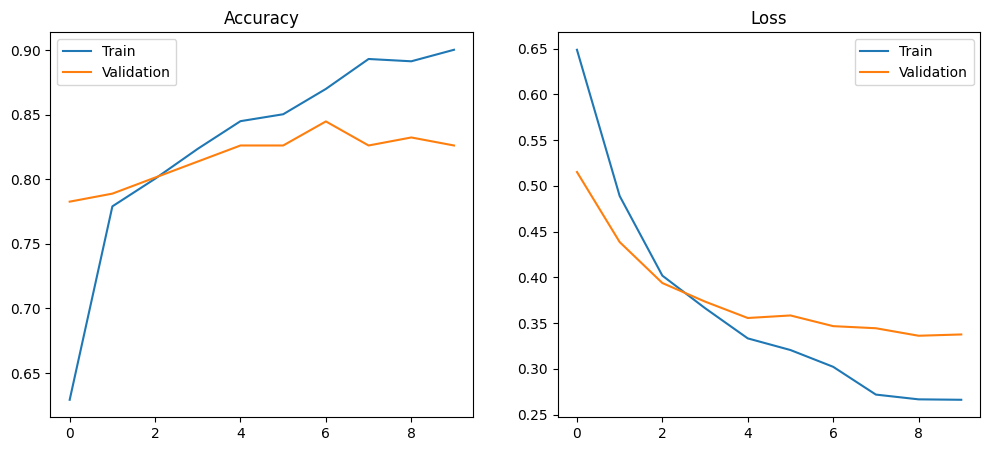

In [64]:
# Plot Accuracy & Loss

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.savefig(os.path.join(OUTPUT_PATH, "training_curves.png"))

plt.show()

In [65]:
# Generate Predictions

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)

    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy())

    y_pred.extend(predictions.flatten())

In [66]:
# Classification Report

report = classification_report(
    y_true,
    y_pred
)

print(report)

with open(
    os.path.join(OUTPUT_PATH, "classification_report.txt"),
    "w"
) as f:

    f.write(report)

              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93        51
         1.0       0.87      0.90      0.88        29

    accuracy                           0.91        80
   macro avg       0.90      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80



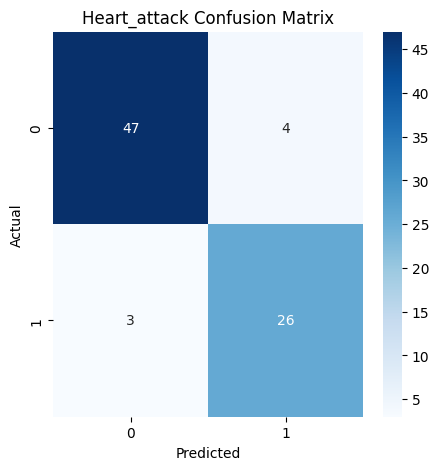

In [67]:
import seaborn as sns

# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"{DISEASE_NAME} Confusion Matrix")

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "confusion_matrix.png"
    )
)

plt.show()

## 10. Save Model


In [68]:
# Save Final Model

model.save(MODEL_PATH)

print(f"Model saved to:\n{MODEL_PATH}")

Model saved to:
C:\Users\KAUSHIKA G\Desktop\MedAssist AI\Image_Model\models\heart_attack_model.keras


## 11. Predict Sample Images

In [69]:
# Predict Single Image

from PIL import Image
import numpy as np

def predict_image(image_path):

    # Load image
    image = Image.open(image_path).convert("RGB")
    image = image.resize(IMAGE_SIZE)

    # Convert to numpy
    image_array = np.array(image) / 255.0

    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # Prediction
    prediction = model.predict(image_array, verbose=0)[0][0]

    # Predicted Class
    predicted_label = 1 if prediction >= 0.5 else 0

    return predicted_label, prediction

In [70]:
# Display Prediction

def show_prediction(image_path):

    label, confidence = predict_image(image_path)

    plt.figure(figsize=(5,5))

    image = Image.open(image_path)

    plt.imshow(image)

    plt.axis("off")

    print("Disease :", DISEASE_NAME)
    print("Prediction :", CLASS_NAMES[label])
    print(f"Confidence : {confidence:.2%}")

    plt.show()

Disease : Heart_attack
Prediction : Normal
Confidence : 19.48%


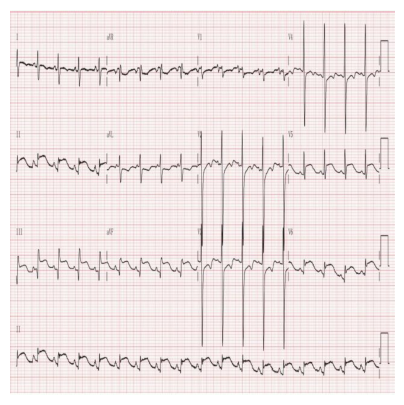

In [73]:
import os

if DATASET_TYPE == "csv":

    sample_image = test_df.iloc[0]["filepath"]

else:

    sample_image = None

    for class_name in os.listdir(TEST_PATH):

        class_path = os.path.join(TEST_PATH, class_name)

        if os.path.isdir(class_path):

            files = os.listdir(class_path)

            if files:
                sample_image = os.path.join(class_path, files[0])
                break

show_prediction(sample_image)

In [74]:
import os

print(MODEL_PATH)
print(os.path.exists(MODEL_PATH))

C:\Users\KAUSHIKA G\Desktop\MedAssist AI\Image_Model\models\heart_attack_model.keras
True


In [75]:
from tensorflow.keras.models import load_model

saved_model = load_model(MODEL_PATH)

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
sample_image = test_df.iloc[0]["filepath"]

model = saved_model

show_prediction(sample_image)

In [76]:
import os

models = [
    "glaucoma_model.keras",
    "brain_stroke_model.keras",
    "diabetic_retinopathy_model.keras",
    "heart_attack_model.keras"
]

for model_name in models:
    path = os.path.join(PROJECT_ROOT, "models", model_name)
    print(model_name, ":", os.path.exists(path))

glaucoma_model.keras : True
brain_stroke_model.keras : True
diabetic_retinopathy_model.keras : True
heart_attack_model.keras : True
